# Brain Tumor Inference Notebook

This notebook loads the saved model and predicts class labels for new images.

In [10]:
from pathlib import Path
import json
import random

import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights, ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)

PyTorch version: 2.10.0+cpu


In [2]:
PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODEL_PATH = ARTIFACTS_DIR / 'best_brain_tumor_model.pth'
CLASS_MAP_PATH = ARTIFACTS_DIR / 'class_mapping.json'

print('MODEL_PATH exists:', MODEL_PATH.exists())
print('CLASS_MAP_PATH exists:', CLASS_MAP_PATH.exists())

MODEL_PATH exists: True
CLASS_MAP_PATH exists: True


In [5]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def build_basic_cnn(num_classes: int):
    return BasicCNN(num_classes=num_classes)


def build_resnet50_transfer(num_classes: int):
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_efficientnet_b0_transfer(num_classes: int):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_name = checkpoint['model_name']
idx_to_class = checkpoint['idx_to_class']
# JSON keys may be strings; normalize to int keys
idx_to_class = {int(k): v for k, v in idx_to_class.items()}
num_classes = len(idx_to_class)
img_size = int(checkpoint.get('img_size', 224))

if model_name == 'Basic CNN':
    model = build_basic_cnn(num_classes)
elif model_name == 'ResNet50':
    model = build_resnet50_transfer(num_classes)
elif model_name == 'EfficientNet-B0':
    model = build_efficientnet_b0_transfer(num_classes)
else:
    raise ValueError(f'Unsupported model_name in checkpoint: {model_name}')

model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()

infer_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

print('Loaded model:', model_name)
print('Device:', device)
print('Image size:', img_size)
print('Classes:', idx_to_class)

Loaded model: ResNet50
Device: cpu
Image size: 224
Classes: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


In [6]:
def predict_image(image_path: Path):
    image_path = Path(image_path)
    with Image.open(image_path).convert('RGB') as img:
        x = infer_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu()

    pred_idx = int(torch.argmax(probs).item())
    pred_label = idx_to_class[pred_idx]
    pred_conf = float(probs[pred_idx].item())

    prob_dict = {idx_to_class[i]: float(probs[i].item()) for i in range(len(probs))}
    return pred_label, pred_conf, prob_dict

Image: c:\Users\acer\Desktop\Brain_Tumor_Classification\Dataset\Testing\pituitary\Te-pi_320.jpg
True label: pituitary
Prediction: pituitary
Confidence: 0.8643
Class probabilities: {'glioma': 0.009447497315704823, 'meningioma': 0.12045123428106308, 'notumor': 0.005841370671987534, 'pituitary': 0.8642599582672119}
Correct: True
------------------------------------------------------------
Image: c:\Users\acer\Desktop\Brain_Tumor_Classification\Dataset\Testing\pituitary\Te-pi_282.jpg
True label: pituitary
Prediction: pituitary
Confidence: 0.8877
Class probabilities: {'glioma': 0.010938537307083607, 'meningioma': 0.04500708729028702, 'notumor': 0.05634712055325508, 'pituitary': 0.8877072334289551}
Correct: True
------------------------------------------------------------
Image: c:\Users\acer\Desktop\Brain_Tumor_Classification\Dataset\Testing\notumor\Te-no_95.jpg
True label: notumor
Prediction: notumor
Confidence: 0.9633
Class probabilities: {'glioma': 0.0027625923976302147, 'meningioma': 0.

,image_path,true_label,prediction,confidence,is_correct
0,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,pituitary,pituitary,0.8643,True
1,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,pituitary,pituitary,0.8877,True
2,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,notumor,notumor,0.9633,True
3,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,meningioma,0.5002,False
4,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,meningioma,meningioma,0.7247,True
5,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,pituitary,pituitary,0.8187,True


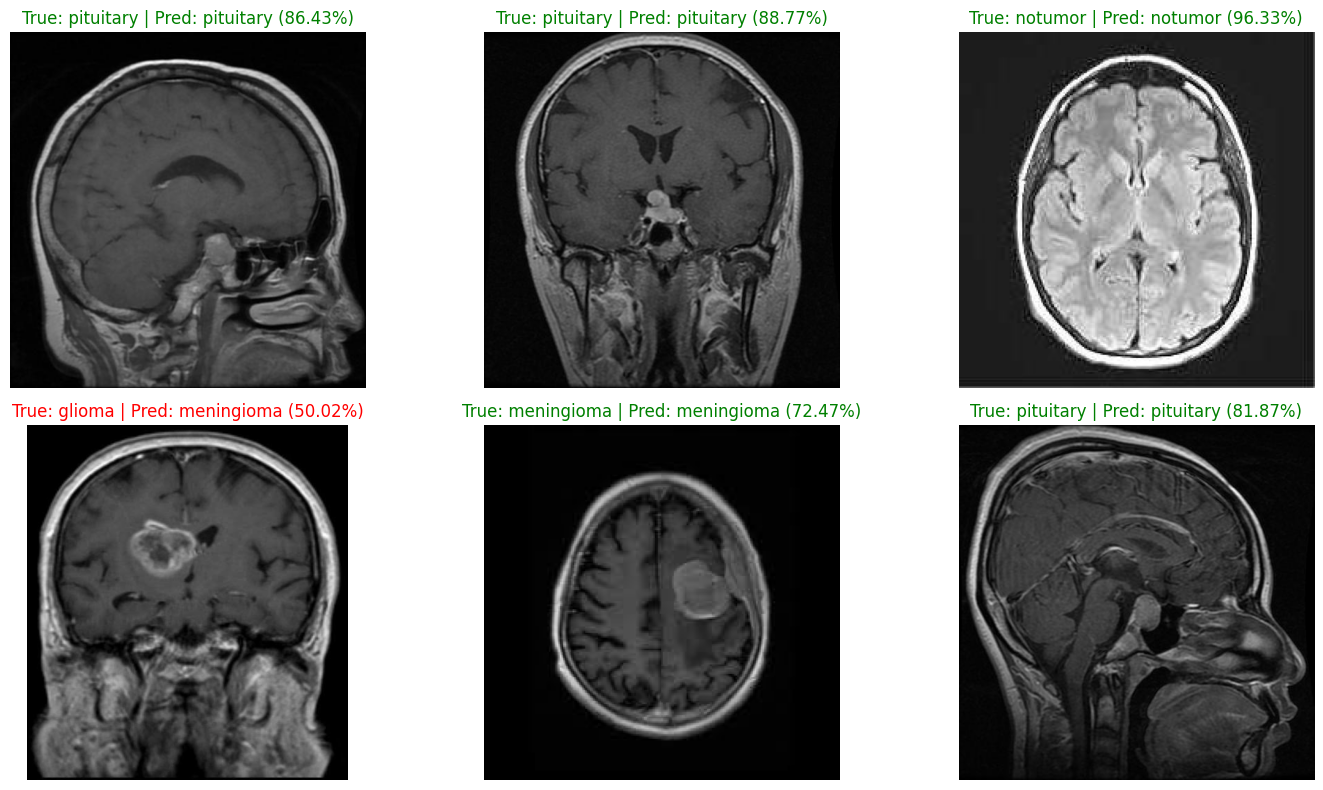

In [17]:
# Multi-image prediction (6 random images by default)
# Optional: set TEST_IMAGES = [Path(...), Path(...)] to use your own images.
TEST_IMAGES = None
NUM_RANDOM_IMAGES = 6

exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
if TEST_IMAGES is None:
    test_root = PROJECT_ROOT / 'Dataset' / 'Testing'
    all_images = [p for p in test_root.rglob('*') if p.is_file() and p.suffix.lower() in exts]
    if not all_images:
        raise FileNotFoundError(f'No test images found in: {test_root}')
    n_select = min(NUM_RANDOM_IMAGES, len(all_images))
    TEST_IMAGES = random.sample(all_images, k=n_select)
else:
    TEST_IMAGES = [Path(p) for p in TEST_IMAGES]

rows = []
for image_path in TEST_IMAGES:
    true_label = image_path.parent.name.lower()
    pred_label, pred_conf, prob_dict = predict_image(image_path)
    is_correct = pred_label.lower() == true_label
    rows.append({
        'image_path': str(image_path),
        'true_label': true_label,
        'prediction': pred_label,
        'confidence': round(pred_conf, 4),
        'is_correct': is_correct,
    })
    print('Image:', image_path)
    print('True label:', true_label)
    print('Prediction:', pred_label)
    print('Confidence:', round(pred_conf, 4))
    print('Class probabilities:', prob_dict)
    print('Correct:', is_correct)
    print('-' * 60)

preview_df = pd.DataFrame(rows)
display(preview_df)

cols = 3
n_imgs = len(TEST_IMAGES)
n_rows = (n_imgs + cols - 1) // cols
fig, axes = plt.subplots(n_rows, cols, figsize=(5 * cols, 4 * n_rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, image_path in enumerate(TEST_IMAGES):
    true_label = image_path.parent.name.lower()
    img = Image.open(image_path).convert('RGB')
    pred_label, pred_conf, _ = predict_image(image_path)
    is_correct = pred_label.lower() == true_label
    title_color = 'green' if is_correct else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {true_label} | Pred: {pred_label} ({pred_conf:.2%})',
        color=title_color,
    )
    axes[i].axis('off')

for j in range(n_imgs, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Batch prediction for a folder (default path is used automatically)
# You can still override by setting IMAGE_FOLDER to any folder path.
IMAGE_FOLDER = PROJECT_ROOT / 'Dataset' / 'Testing'

IMAGE_FOLDER = Path(IMAGE_FOLDER)
if not IMAGE_FOLDER.exists() or not IMAGE_FOLDER.is_dir():
    raise FileNotFoundError(f'Invalid IMAGE_FOLDER: {IMAGE_FOLDER}')

exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
image_files = [p for p in IMAGE_FOLDER.rglob('*') if p.is_file() and p.suffix.lower() in exts]

if not image_files:
    raise FileNotFoundError(f'No supported image files found in: {IMAGE_FOLDER}')

rows = []
for p in sorted(image_files):
    pred_label, pred_conf, _ = predict_image(p)
    rows.append({
        'image_path': str(p),
        'pred_label': pred_label,
        'confidence': round(pred_conf, 4),
    })

pred_df = pd.DataFrame(rows)
display(pred_df.head(20))
print('Folder used:', IMAGE_FOLDER)
print('Total predicted images:', len(pred_df))

,image_path,pred_label,confidence
0,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.5521
1,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.9725
2,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.9961
3,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,meningioma,0.6161
4,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,notumor,0.3216
5,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.7143
6,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,meningioma,0.4647
7,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.8293
8,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,notumor,0.5451
9,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.8909


Folder used: c:\Users\acer\Desktop\Brain_Tumor_Classification\Dataset\Testing
Total predicted images: 1600


In [13]:
# Export all batch predictions to CSV automatically
EXPORT_CSV_PATH = PROJECT_ROOT / 'artifacts' / 'batch_predictions.csv'
EXPORT_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

if 'pred_df' not in globals() or pred_df is None or pred_df.empty:
    print('pred_df not found. Generating batch predictions first...')
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    image_files = [p for p in Path(IMAGE_FOLDER).rglob('*') if p.is_file() and p.suffix.lower() in exts]
    rows = []
    for p in sorted(image_files):
        pred_label, pred_conf, _ = predict_image(p)
        rows.append({
            'image_path': str(p),
            'pred_label': pred_label,
            'confidence': round(pred_conf, 4),
        })
    pred_df = pd.DataFrame(rows)

pred_df.to_csv(EXPORT_CSV_PATH, index=False)
print('Saved batch predictions to:', EXPORT_CSV_PATH)
print('Total rows saved:', len(pred_df))
display(pred_df.head(10))

Saved batch predictions to: c:\Users\acer\Desktop\Brain_Tumor_Classification\artifacts\batch_predictions.csv
Total rows saved: 1600


,image_path,pred_label,confidence
0,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.5521
1,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.9725
2,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.9961
3,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,meningioma,0.6161
4,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,notumor,0.3216
5,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.7143
6,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,meningioma,0.4647
7,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.8293
8,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,notumor,0.5451
9,c:\Users\acer\Desktop\Brain_Tumor_Classificati...,glioma,0.8909
